In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("../data/raw/results.csv")
print(f"Loaded {len(df)} raw matches")

Loaded 49477 raw matches


In [3]:
# ---- Parse dates ----
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [4]:
# ---- Filter to matches from 1990 onward ----
before = len(df)
df = df[df["year"] >= 1990].copy()
print(f"Filtered to 1990+: {before} -> {len(df)} rows")


Filtered to 1990+: 49477 -> 32359 rows


In [5]:
# ---- Handle missing values ----
cols_needed = ["home_team", "away_team", "home_score", "away_score", "neutral"]
null_counts = df[cols_needed].isnull().sum()

if null_counts.sum() > 0:
    print("\nNulls found before cleaning:")
    print(null_counts[null_counts > 0])
else:
    print("\nNo nulls found in required columns")

before = len(df)
df = df.dropna(subset=cols_needed).copy()
print(f"After dropping nulls: {before} -> {len(df)} rows")




Nulls found before cleaning:
home_score    44
away_score    44
dtype: int64
After dropping nulls: 32359 -> 32315 rows


In [6]:
# ---- Sanity check scores are valid numbers ----
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")
before = len(df)
df = df.dropna(subset=["home_score", "away_score"]).copy()
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)
if before != len(df):
    print(f"Dropped {before - len(df)} rows with invalid score values")

In [7]:
# ---- Remove exact duplicate matches ----
before = len(df)
df = df.drop_duplicates(subset=["date", "home_team", "away_team",
                                 "home_score", "away_score"])
if before != len(df):
    print(f"Removed {before - len(df)} duplicate rows")

Removed 1 duplicate rows


In [8]:
# ---- Create the target column: result ----
df["result"] = np.where(
    df["home_score"] > df["away_score"], "Home Win",
    np.where(df["away_score"] > df["home_score"], "Away Win", "Draw")
)

print("\n=== Result distribution ===")
counts = df["result"].value_counts()
pcts = df["result"].value_counts(normalize=True).round(3)
summary = pd.DataFrame({"count": counts, "pct": pcts})
print(summary)


=== Result distribution ===
          count    pct
result                
Home Win  15666  0.485
Away Win   9048  0.280
Draw       7600  0.235


In [9]:

# ---- Flag class imbalance if severe ----
min_pct = pcts.min()
if min_pct < 0.15:
    print(f"\nWarning: smallest class is only {min_pct:.1%} of data — "
          f"may need class_weight='balanced' when training later")


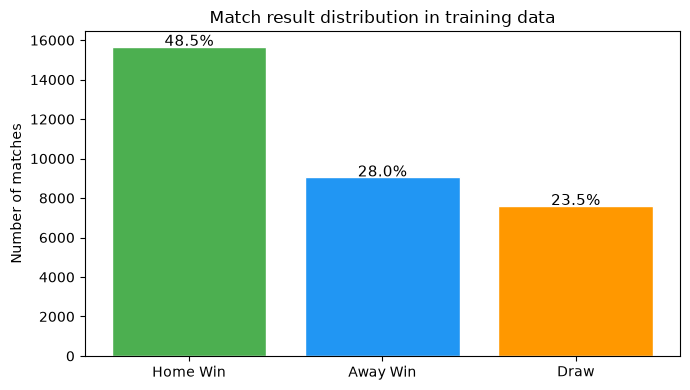

In [10]:
# ---- Visualize class balance ----
plt.figure(figsize=(7, 4))
colors = {"Home Win": "#4CAF50", "Away Win": "#2196F3", "Draw": "#FF9800"}
bar_colors = [colors[r] for r in counts.index]
bars = plt.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
plt.title("Match result distribution in training data")
plt.ylabel("Number of matches")

for bar, val in zip(bars, counts.values):
    pct = val / len(df)
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
              f"{pct:.1%}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
# ---- Final integrity check before saving ----
required_cols = ["date", "home_team", "away_team", "home_score",
                  "away_score", "neutral", "result"]
assert df[required_cols].isnull().sum().sum() == 0, "Nulls still present!"
assert df["result"].isin(["Home Win", "Away Win", "Draw"]).all(), "Bad result values!"
print("\nIntegrity check passed")


Integrity check passed


In [12]:
# ---- Save cleaned data ----
os.makedirs("../data/processed", exist_ok=True)
output_path = "../data/processed/clean_matches.csv"
df.to_csv(output_path, index=False)

print(f"\nSaved {len(df)} clean matches to {output_path}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")


Saved 32314 clean matches to ../data/processed/clean_matches.csv
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'year', 'month', 'result']
Date range: 1990-01-12 to 2026-06-18
